In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
import tensorflow as tf
import numpy as np
import librosa
import pandas as pd
import sklearn
import seaborn as sns
import umap
import pyaudio
import os

I0000 00:00:1778838859.821415   29098 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778838860.017758   29098 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778838863.767646   29098 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [22]:
from IPython.display import Audio, display, update_display, HTML

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("brinkor/vehicle-type-sound-dataset")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████| 524M/524M [00:38<00:00, 14.2MB/s]

Extracting files...


Path to dataset files: /home/nimcompoo/.cache/kagglehub/datasets/brinkor/vehicle-type-sound-dataset/versions/1


## Loading a labeled set of data

In [21]:
labeled_data = pd.read_csv(os.path.join(path, 'vehicle_type_sound_dataset/labels.csv'))
labeled_data

,file_path,class
0,cutted_files/VehicleNoise0.wav,1
1,cutted_files/VehicleNoise1.wav,0
2,cutted_files/VehicleNoise2.wav,0
3,cutted_files/VehicleNoise3.wav,0
4,cutted_files/VehicleNoise4.wav,1
...,...,...
1700,cutted_files/VehicleNoise1700.wav,0
1701,cutted_files/VehicleNoise1701.wav,1
1702,cutted_files/VehicleNoise1702.wav,1
1703,cutted_files/VehicleNoise1703.wav,0


In [47]:
additional_data = pd.read_csv(os.path.join(path, 'vehicle_type_sound_dataset/labels_with_additional_data.csv'))
additional_data

,file_path,class
0,data/additional/car/auto_30kph_pass1_1.wav,0
1,data/additional/car/auto_30kph_pass2_1.wav,0
2,data/additional/car/auto_30kph_pass3_1.wav,0
3,data/additional/car/auto_50kph_pass1_1.wav,0
4,data/additional/car/auto_50kph_pass2_1.wav,0
...,...,...
1758,cutted_files/VehicleNoise1700.wav,0
1759,cutted_files/VehicleNoise1701.wav,1
1760,cutted_files/VehicleNoise1702.wav,1
1761,cutted_files/VehicleNoise1703.wav,0


## Load the embedder network

In [1]:
# Download the latest version of the CNN14 Keras port
panns_path = kagglehub.model_download("yassienwasfy/cnn14-panns-keras-port/keras/default")
#panns_model = tf.saved_model.load(panns_path)
print("Path to model files:", panns_path)

NameError: name 'kagglehub' is not defined

In [19]:
model_path = kagglehub.model_download("google/yamnet/tensorFlow2/yamnet")
model = tf.saved_model.load(model_path)
class_map_path = f"{model_path}/assets/yamnet_class_map.csv"
class_names = pd.read_csv(class_map_path)['display_name'].tolist()

E0000 00:00:1778824922.658810    3999 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## generate all the embeddings for the said dataset

In [161]:
file_path = os.path.join(path, 'vehicle_type_sound_dataset', labeled_data.loc[3, 'file_path'])
#file_path = 'HornAudios/mixkit-clown-longhorn-727.wav'
audio, _ = librosa.load(file_path, sr=16000, mono=True, duration=4)

In [163]:
Audio(data=audio, rate=16000)

## Create all the embeddings

In [164]:
import scipy

In [165]:
#low_pass_horn = 1800
high_pass_horn = 3350
low_pass_horn=350
#high_pass_horn=851

In [166]:
def generate_embeddings(audio, sr):
    audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
    filterer = scipy.signal.butter(5, [low_pass_horn, high_pass_horn], btype='bandpass', analog=False, output='sos', fs=16000)
    filtered = scipy.signal.sosfiltfilt(filterer, audio)
    return filtered

In [167]:
filtered = generate_embeddings(audio, 16000)

In [168]:
Audio(data=filtered, rate=16000)

<Axes: >

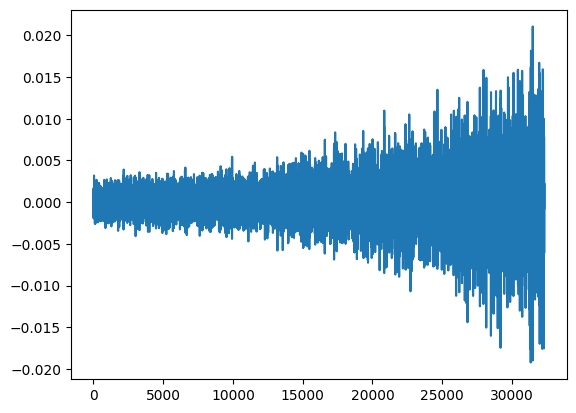

In [169]:
sns.lineplot(filtered)
#sns.lineplot(audio)

<Axes: >

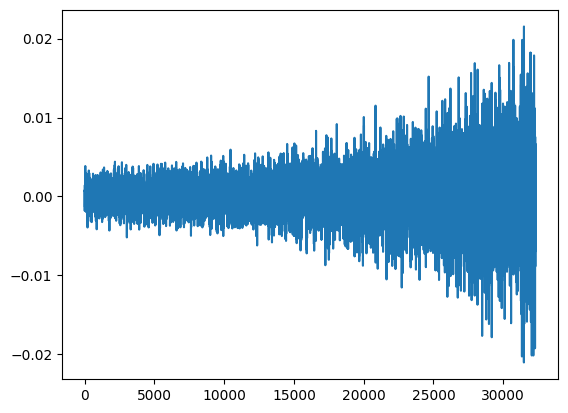

In [170]:
sns.lineplot(audio)